# Matplotlib & Seaborn Charts

A simple collection of chart examples.

## Importing

In [54]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

We use small, built-in datasets.
This way the notebook works with no extra files.

In [55]:
salary_df = pd.read_csv ("../data/salary_data.csv")

# Load Seaborn's built-in datasets
tips = sns.load_dataset ("tips")
fmri = sns.load_dataset ("fmri")
penguins = sns.load_dataset ("penguins")

## Line Charts

A line chart shows how a value changes.

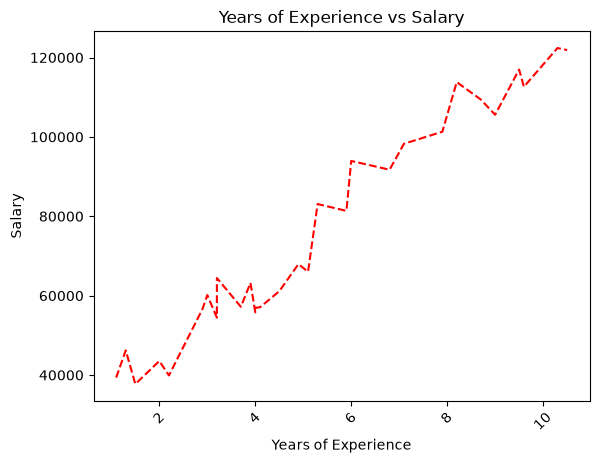

In [56]:
### Line Plot (Matplotlib)
plt.plot (salary_df ["YearsExperience"], salary_df ["Salary"], "r--")
plt.xticks (rotation = 45)
plt.title ("Years of Experience vs Salary")
plt.xlabel ("Years of Experience")
plt.ylabel ("Salary")
plt.show ()

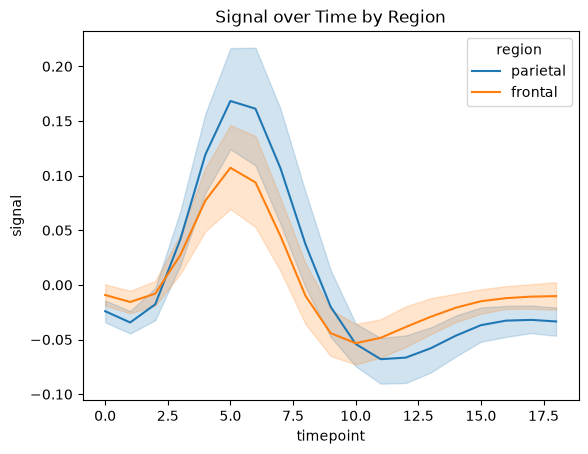

In [57]:
### Line Plot with Groups (Seaborn)
# hue splits the lines by group
sns.lineplot (data= fmri, x= "timepoint", y= "signal", hue= "region")
plt.title ("Signal over Time by Region")
plt.show ()

## Scatter Plots

A scatter plot shows the relationship between two values.

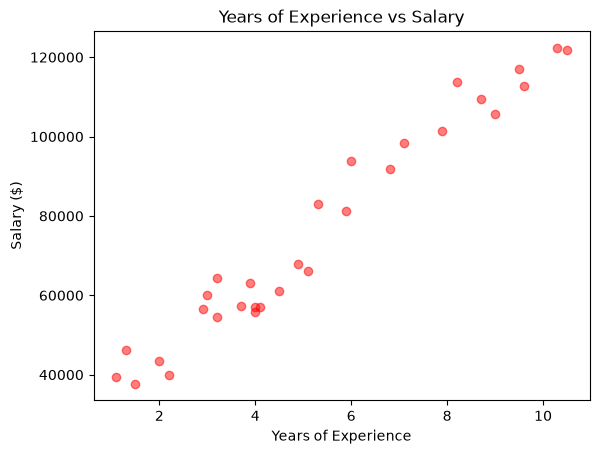

In [58]:
### Scatter Plot (Matplotlib)
plt.scatter (salary_df ["YearsExperience"], salary_df ["Salary"], color= "red", alpha= 0.5)
plt.title ("Years of Experience vs Salary")
plt.xlabel ("Years of Experience")
plt.ylabel ("Salary ($)")
plt.show ()

## Bar Charts

A bar chart compares values across groups.

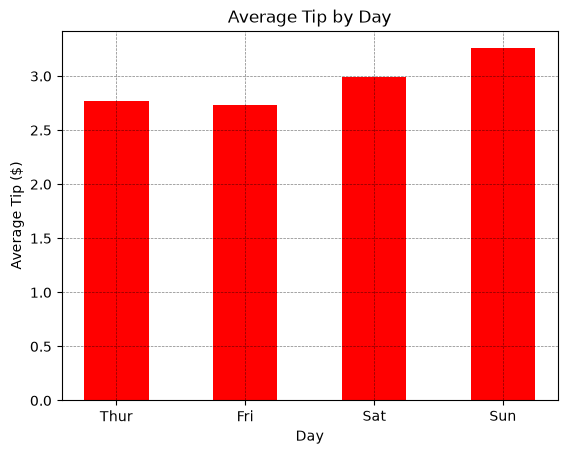

In [59]:
### Bar Chart (Matplotlib)
avg_tip_per_day = tips.groupby("day")["tip"].mean()

plt.bar(avg_tip_per_day.index, avg_tip_per_day.values, color="red", width=0.5)
plt.grid(color="black", linestyle="--", linewidth=0.5, alpha=0.5)
plt.title("Average Tip by Day")
plt.xlabel("Day")
plt.ylabel("Average Tip ($)")
plt.show()

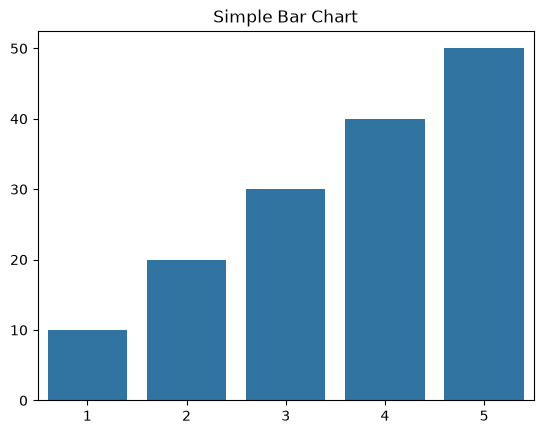

In [60]:
### Bar Chart (Seaborn)
x = [1, 2, 3, 4, 5]
y = [10, 20, 30, 40, 50]

sns.barplot (x=x, y=y)
plt.title ("Simple Bar Chart")
plt.show ()

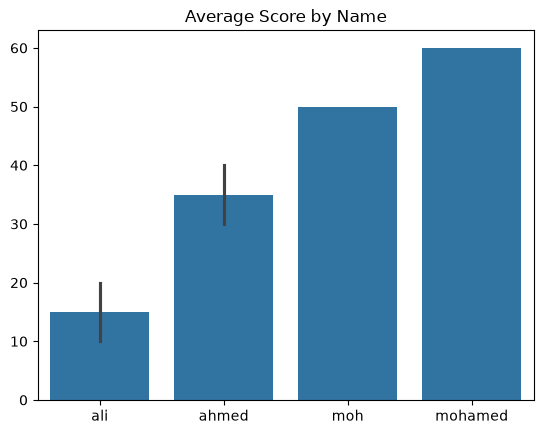

In [61]:
### Bar Chart with Repeated Categories (Seaborn)
# Seaborn takes the mean when a category repeats
names = ["ali", "ali", "ahmed", "ahmed", "moh", "mohamed"]
scores = [10, 20, 30, 40, 50, 60]

sns.barplot(x=names, y=scores)
plt.title ("Average Score by Name")
plt.show ()

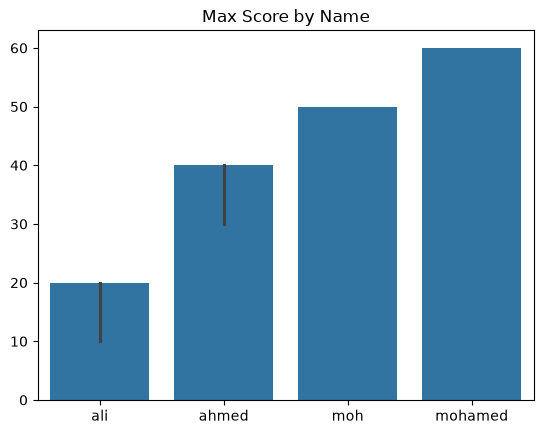

In [62]:
### Bar Chart with Max Value (Seaborn)
# estimator=max shows the max value instead of the mean
sns.barplot(x=names, y=scores, estimator=max)
plt.title("Max Score by Name")
plt.show()

smoker       Yes        No
sex                       
Male    3.051167  3.113402
Female  2.931515  2.773519


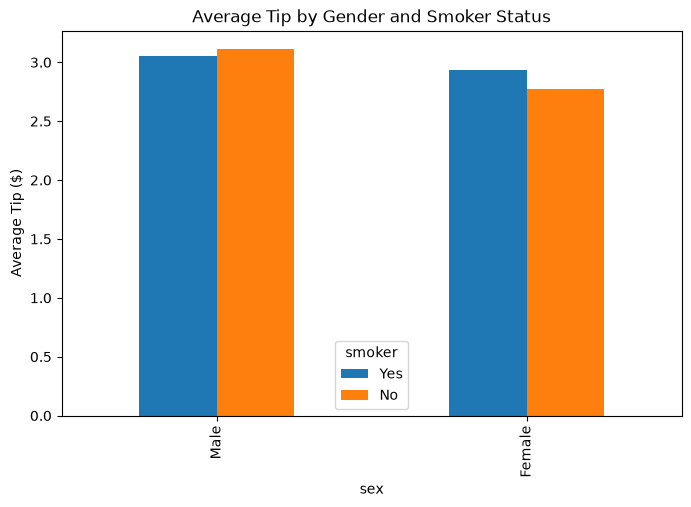

In [63]:
### Grouped Bar Chart (Pandas)
# Compare tip by gender and smoker status
grouped = tips.groupby(["sex", "smoker"])["tip"].mean().unstack()

print (grouped)

grouped.plot(kind="bar", figsize=(8, 5))
plt.title("Average Tip by Gender and Smoker Status")
plt.ylabel("Average Tip ($)")
plt.show()

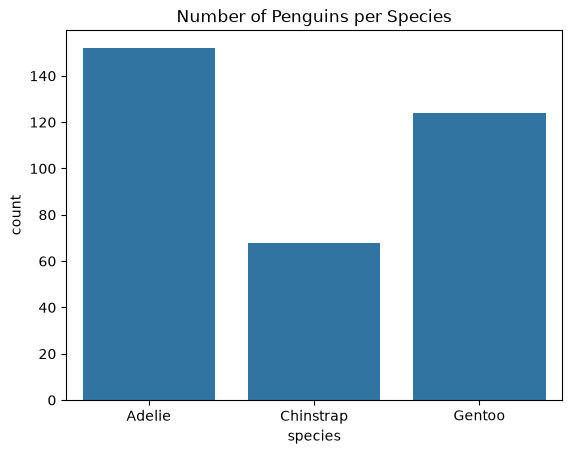

In [64]:
### Count Plot (Seaborn)
# Counts how many rows are in each group
sns.countplot (x=penguins["species"])
plt.title ("Number of Penguins per Species")
plt.show ()

## Histograms

A histogram shows how values are spread out.

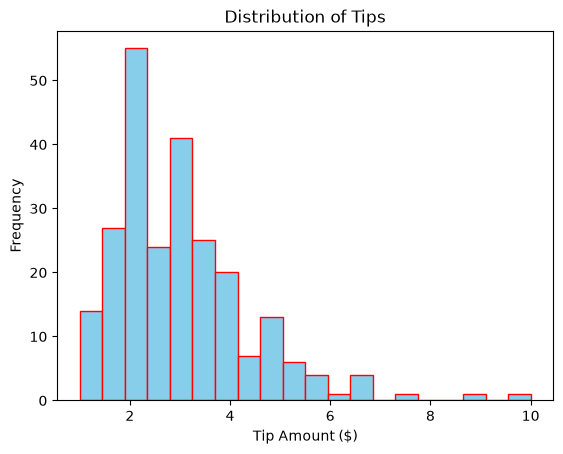

In [65]:
### Histogram (Matplotlib)
plt.hist(tips["tip"], bins=20, color="skyblue", edgecolor="red")
plt.title("Distribution of Tips")
plt.xlabel("Tip Amount ($)")
plt.ylabel("Frequency")
plt.show()

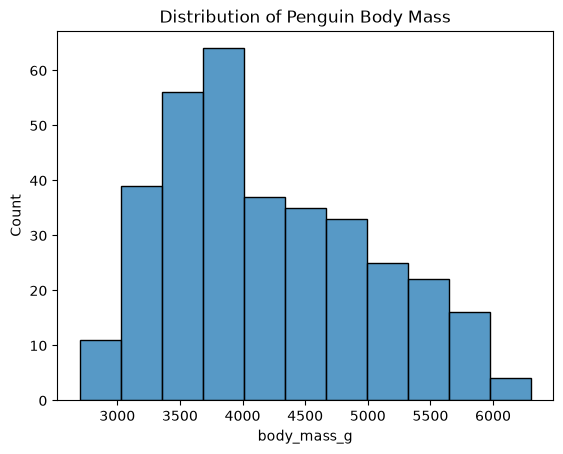

In [66]:
### Histogram (Seaborn)
sns.histplot(penguins["body_mass_g"])
plt.title("Distribution of Penguin Body Mass")
plt.show()

## Box Plots

A box plot shows the spread of data and outliers.

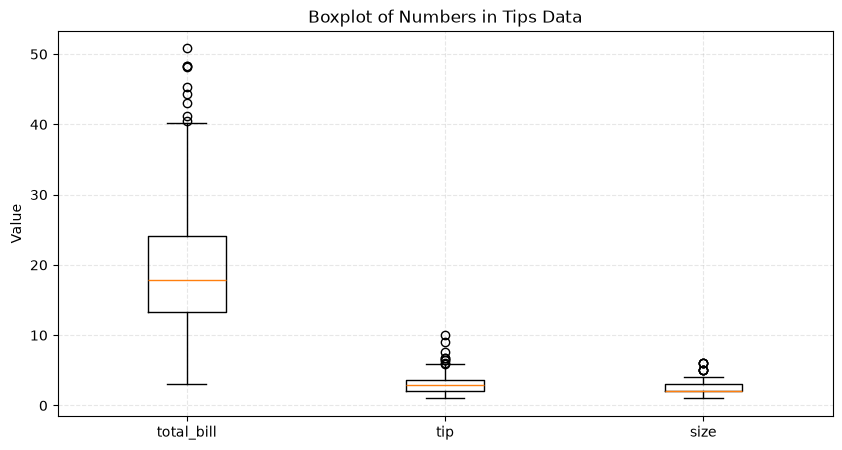

In [67]:
### Box Plot of Several Columns (Matplotlib)
plt.figure(figsize=(10, 5))
plt.boxplot([tips["total_bill"], tips["tip"], tips["size"]],
            tick_labels=["total_bill", "tip", "size"])
plt.title("Boxplot of Numbers in Tips Data")
plt.ylabel("Value")
plt.grid(True, linestyle="--", alpha=0.3)
plt.show()

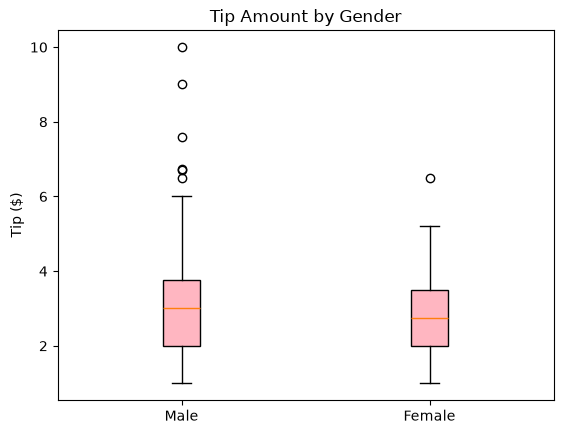

In [ ]:
### Box Plot by Group (Matplotlib)
plt.boxplot([
    tips[tips["sex"] == "Male"]["tip"],
    tips[tips["sex"] == "Female"]["tip"]
], tick_labels=["Male", "Female"], patch_artist=True,
   boxprops=dict(facecolor="lightpink"))

plt.title("Tip Amount by Gender")
plt.ylabel("Tip ($)")
plt.show()

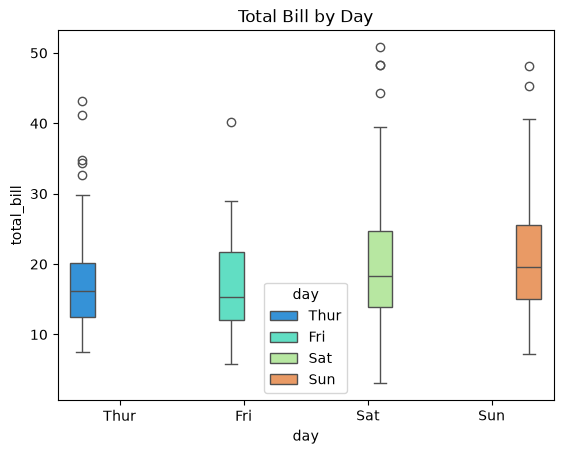

In [79]:
### Box Plot by Group (Seaborn)
sns.boxplot(x="day", y="total_bill", hue="day", data=tips, palette="rainbow", legend=True)
plt.title("Total Bill by Day")
plt.show()

## Pie Charts

A pie chart shows parts of a whole.

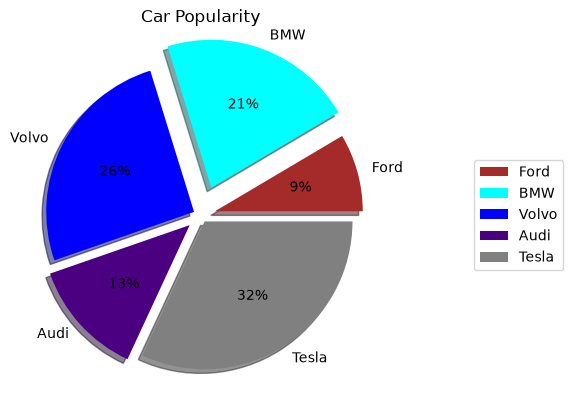

In [70]:
### Pie Chart (Matplotlib)
cars = ["Ford", "BMW", "Volvo", "Audi", "Tesla"]
values = [20, 50, 60, 30, 75]
colors = ["brown", "cyan", "blue", "indigo", "gray"]

plt.pie(values, labels=cars, colors=colors,
        explode=[0.1, 0.2, 0.05, 0.1, 0.05],
        autopct="%1.0f%%", shadow=True)
plt.legend(cars, loc="center right", bbox_to_anchor=(1, 0, 0.5, 1))
plt.title("Car Popularity")
plt.show()

## Subplots

Subplots show many charts in one figure.

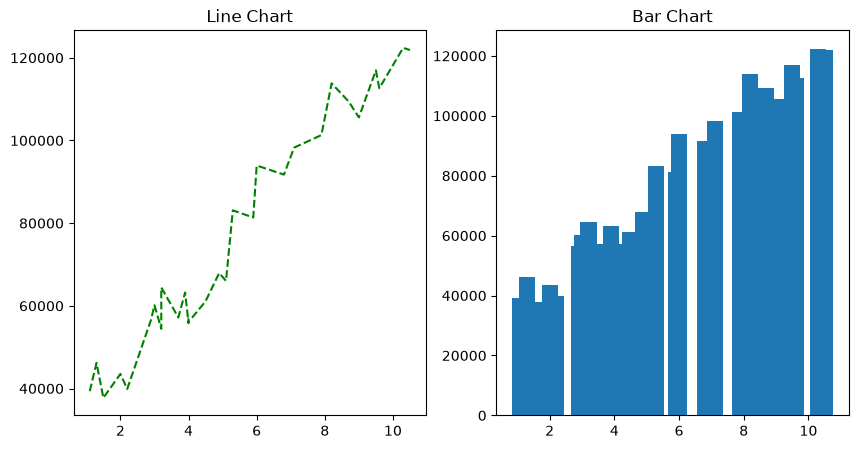

In [71]:
### Two Different Charts Together
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.plot(salary_df["YearsExperience"], salary_df["Salary"], "g--")
plt.title("Line Chart")

plt.subplot(1, 2, 2)
plt.bar(salary_df["YearsExperience"], salary_df["Salary"], width=0.5)
plt.title("Bar Chart")

plt.show()

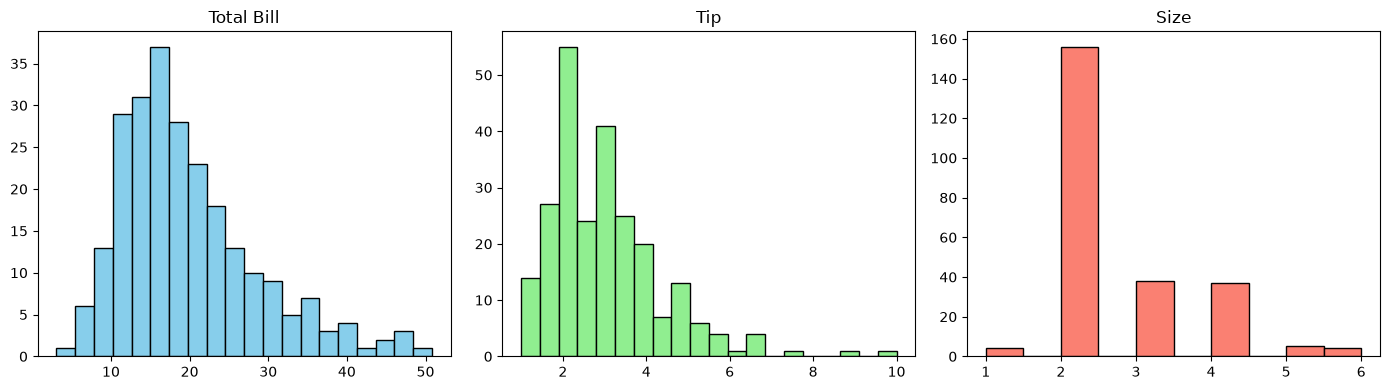

In [72]:
### Three Histograms in a Row
plt.figure(figsize=(14, 4))

plt.subplot(1, 3, 1)
plt.hist(tips["total_bill"], bins=20, color="skyblue", edgecolor="black")
plt.title("Total Bill")

plt.subplot(1, 3, 2)
plt.hist(tips["tip"], bins=20, color="lightgreen", edgecolor="black")
plt.title("Tip")

plt.subplot(1, 3, 3)
plt.hist(tips["size"], bins=10, color="salmon", edgecolor="black")
plt.title("Size")

plt.tight_layout()
plt.show()

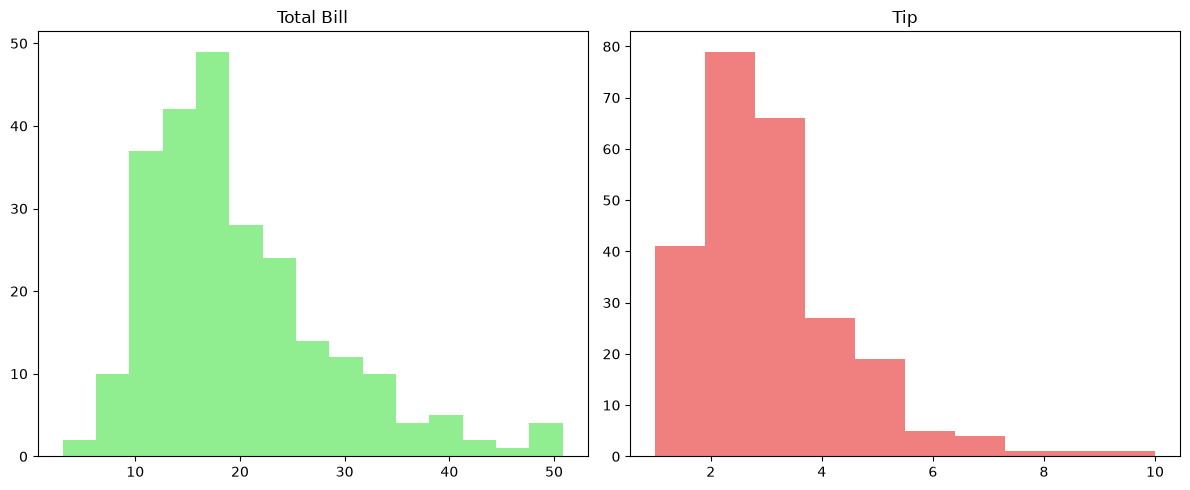

In [73]:
### Subplots the Object-Oriented Way
# fig and axes give you more control over each chart
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(tips["total_bill"], bins=15, color="lightgreen")
axes[0].set_title("Total Bill")

axes[1].hist(tips["tip"], bins=10, color="lightcoral")
axes[1].set_title("Tip")

plt.tight_layout()
plt.show()

## Other Useful Charts

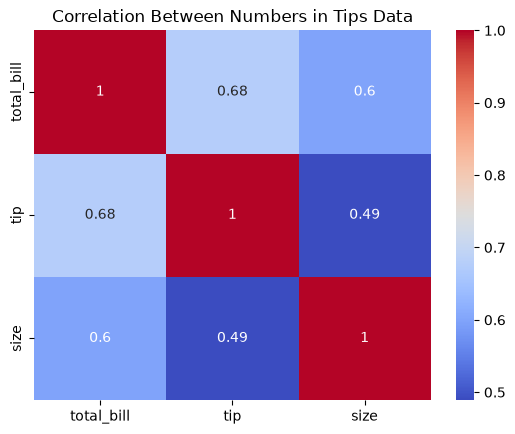

In [75]:
### Correlation Heatmap (Seaborn)
# Shows how numbers relate to each other
corr = tips.corr(numeric_only=True)

sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Between Numbers in Tips Data")
plt.show()